# Metin Ön İşleme Adımları — NLP Final Ödevi

Bu defter, BBC News makalelerinden oluşan gerçek dünya veri seti üzerinde 
temel metin ön işleme adımlarını uygulamak amacıyla hazırlanmıştır.
Her işlem adımı için açıklama ve Önce/Sonra çıktıları sunulmaktadır.

## 1. Veri Seti Bilgileri

- **Kaynak:** Kaggle — BBC News Articles Dataset  
  URL: https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive  
  Yöntem: Kaggle web sitesinden manuel olarak CSV formatında indirilmiştir.
- **Boyut:** 2.225 makale, ~5 MB, CSV formatı
- **Sütun Yapısı:**

| Sütun | Açıklama |
|-------|----------|
| category | Haber kategorisi (sport, tech, politics, business, entertainment) |
| filename | Dosya adı |
| title | Makalenin başlığı |
| content | Makalenin tam metni |

In [36]:
# Gerekli kütüphanelerin yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

# NLTK verilerini indir
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from collections import Counter

print("Tüm kütüphaneler başarıyla yüklendi.")

Tüm kütüphaneler başarıyla yüklendi.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\amins\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\amins\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amins\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\amins\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [37]:
# Veri setini yükle
df = pd.read_csv('bbc-news-data.csv', sep='\t')

# Sütun isimlerini kontrol et
print("Sütunlar:", df.columns.tolist())
print("Satır sayısı:", len(df))
print("\nİlk 3 satır:")
display(df.head(3))

Sütunlar: ['category', 'filename', 'title', 'content']
Satır sayısı: 2225

İlk 3 satır:


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...


## 2. Ham Veri Üzerinde Zipf Yasası Analizi

Ön işleme yapılmadan önce ham veri üzerinde kelime frekansları hesaplanarak
log-log grafiği çizilmiştir. Zipf Yasası'na göre bir kelimenin frekansı,
sıralamadaki (rank) yeriyle ters orantılıdır.

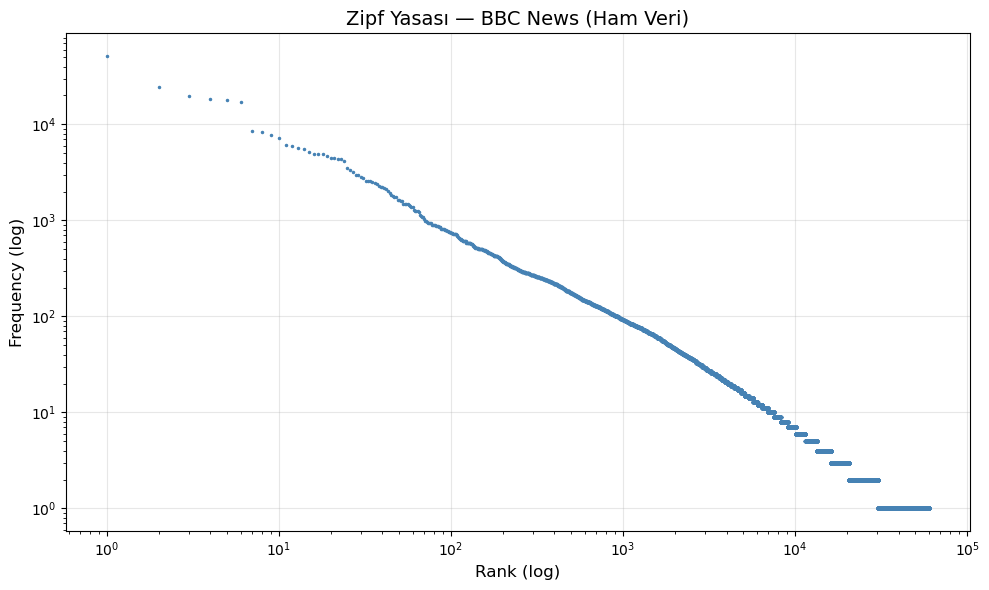

Zipf grafiği oluşturuldu.


In [38]:
# Tüm metni birleştir
all_text = ' '.join(df['content'].dropna().tolist())

# Kelime frekanslarını hesapla
words = all_text.lower().split()
freq = Counter(words)
ranks = range(1, len(freq) + 1)
frequencies = sorted(freq.values(), reverse=True)

# Log-Log grafiği
plt.figure(figsize=(10, 6))
plt.loglog(list(ranks), frequencies, marker='.', linestyle='none',
           markersize=3, color='steelblue')
plt.title("Zipf Yasası — BBC News (Ham Veri)", fontsize=14)
plt.xlabel("Rank (log)", fontsize=12)
plt.ylabel("Frequency (log)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zipf_raw.png', dpi=150)
plt.show()
print("Zipf grafiği oluşturuldu.")


## 3. Ön İşleme Adımları

Aşağıdaki adımlar sırasıyla uygulanmıştır. Her adımda kullanılan
kütüphane belirtilmiş ve Önce/Sonra örnekleri gösterilmiştir.

### 3.1 Genel İçerik Temizliği
HTML etiketleri, sayılar, özel karakterler ve gereksiz semboller
`re` (Regular Expressions) kütüphanesi kullanılarak temizlenmektedir.

In [39]:
# Kütüphane: re (Regular Expressions)
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)        # HTML etiketleri kaldır
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Sayılar ve özel karakterler kaldır
    text = re.sub(r'\s+', ' ', text).strip() # Fazla boşlukları temizle
    return text

df['text_clean'] = df['content'].apply(clean_text)

print("=== ÖNCE ===")
print(df['content'].iloc[0][:300])
print("\n=== SONRA ===")
print(df['text_clean'].iloc[0][:300])

=== ÖNCE ===
 Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fo

=== SONRA ===
Quarterly profits at US media giant TimeWarner jumped to bn m for the three months to December from m yearearlier The firm which is now one of the biggest investors in Google benefited from sales of highspeed internet connections and higher advert sales TimeWarner said fourth quarter sales rose to b


### 3.2 Lowercasing (Küçük Harfe Çevirme)
Modelin 'Hello' ve 'hello' kelimelerini aynı kelime olarak tanıması için
tüm metin küçük harfe dönüştürülür.
Kütüphane: Python built-in `str.lower()`

In [40]:
# Kütüphane: Python built-in str.lower()
df['text_lower'] = df['text_clean'].apply(lambda x: x.lower())

print("=== ÖNCE ===")
print(df['text_clean'].iloc[0][:200])
print("\n=== SONRA ===")
print(df['text_lower'].iloc[0][:200])

=== ÖNCE ===
Quarterly profits at US media giant TimeWarner jumped to bn m for the three months to December from m yearearlier The firm which is now one of the biggest investors in Google benefited from sales of h

=== SONRA ===
quarterly profits at us media giant timewarner jumped to bn m for the three months to december from m yearearlier the firm which is now one of the biggest investors in google benefited from sales of h


### 3.3 Tokenization (Belirteçlere Ayırma)
Metin; cümlelere ve ardından kelimelere ayrılmaktadır.
Noktalama işaretleri bu aşamada kaldırılmaktadır.
Kütüphane: **NLTK** — `word_tokenize`, `sent_tokenize`

In [41]:
# Kütüphane: NLTK
def tokenize_text(text):
    sentences = sent_tokenize(text)   # Cümlelere ayır
    tokens = word_tokenize(text)      # Kelimelere ayır
    tokens = [t for t in tokens if t.isalpha()]  # Noktalama kaldır
    return tokens

df['tokens'] = df['text_lower'].apply(tokenize_text)

print("=== ÖNCE (düz metin) ===")
print(df['text_lower'].iloc[0][:200])
print("\n=== SONRA (token listesi) ===")
print(df['tokens'].iloc[0][:20])

=== ÖNCE (düz metin) ===
quarterly profits at us media giant timewarner jumped to bn m for the three months to december from m yearearlier the firm which is now one of the biggest investors in google benefited from sales of h

=== SONRA (token listesi) ===
['quarterly', 'profits', 'at', 'us', 'media', 'giant', 'timewarner', 'jumped', 'to', 'bn', 'm', 'for', 'the', 'three', 'months', 'to', 'december', 'from', 'm', 'yearearlier']


### 3.4 Stop Word Removal (Durak Kelime Temizleme)
"the", "is", "and" gibi anlam taşımayan kelimeler
**NLTK** stopwords listesi kullanılarak kaldırılmaktadır.

In [42]:
# Kütüphane: NLTK stopwords
stop_words = set(stopwords.words('english'))

df['tokens_nostop'] = df['tokens'].apply(
    lambda tokens: [t for t in tokens if t not in stop_words]
)

print("=== ÖNCE (token sayısı):", len(df['tokens'].iloc[0]))
print("İlk 15 token:", df['tokens'].iloc[0][:15])
print("\n=== SONRA (token sayısı):", len(df['tokens_nostop'].iloc[0]))
print("İlk 15 token:", df['tokens_nostop'].iloc[0][:15])

=== ÖNCE (token sayısı): 402
İlk 15 token: ['quarterly', 'profits', 'at', 'us', 'media', 'giant', 'timewarner', 'jumped', 'to', 'bn', 'm', 'for', 'the', 'three', 'months']

=== SONRA (token sayısı): 233
İlk 15 token: ['quarterly', 'profits', 'us', 'media', 'giant', 'timewarner', 'jumped', 'bn', 'three', 'months', 'december', 'yearearlier', 'firm', 'one', 'biggest']


### 3.5 Lemmatization (Kök Bulma — Sözlük Tabanlı)
Her kelime sözlükteki kök haline getirilir.
Örnek: "running" → "run", "better" → "good"
Kütüphane: **NLTK WordNetLemmatizer**

In [43]:
# Kütüphane: NLTK WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

df['tokens_lemma'] = df['tokens_nostop'].apply(
    lambda tokens: [lemmatizer.lemmatize(t) for t in tokens]
)

print("=== ÖNCE ===")
print(df['tokens_nostop'].iloc[0][:15])
print("\n=== SONRA (Lemmatization) ===")
print(df['tokens_lemma'].iloc[0][:15])

df['text_lemmatized'] = df['tokens_lemma'].apply(lambda t: ' '.join(t))

=== ÖNCE ===
['quarterly', 'profits', 'us', 'media', 'giant', 'timewarner', 'jumped', 'bn', 'three', 'months', 'december', 'yearearlier', 'firm', 'one', 'biggest']

=== SONRA (Lemmatization) ===
['quarterly', 'profit', 'u', 'medium', 'giant', 'timewarner', 'jumped', 'bn', 'three', 'month', 'december', 'yearearlier', 'firm', 'one', 'biggest']


### 3.6 Stemming (Gövdeye İndirgeme)
Kelimelerden ekler koparılarak gövde elde edilir.
Örnek: "running" → "run", "studies" → "studi"
Kütüphane: **NLTK PorterStemmer**

In [44]:
# Kütüphane: NLTK PorterStemmer
stemmer = PorterStemmer()

df['tokens_stem'] = df['tokens_nostop'].apply(
    lambda tokens: [stemmer.stem(t) for t in tokens]
)

print("=== ÖNCE ===")
print(df['tokens_nostop'].iloc[0][:15])
print("\n=== SONRA (Stemming) ===")
print(df['tokens_stem'].iloc[0][:15])

df['text_stemmed'] = df['tokens_stem'].apply(lambda t: ' '.join(t))

=== ÖNCE ===
['quarterly', 'profits', 'us', 'media', 'giant', 'timewarner', 'jumped', 'bn', 'three', 'months', 'december', 'yearearlier', 'firm', 'one', 'biggest']

=== SONRA (Stemming) ===
['quarterli', 'profit', 'us', 'media', 'giant', 'timewarn', 'jump', 'bn', 'three', 'month', 'decemb', 'yearearli', 'firm', 'one', 'biggest']


## 4. CSV Dosyalarının Kaydedilmesi
İşlem görmüş veriler üç ayrı CSV dosyası olarak kaydedilmektedir.

In [45]:
# Ham veri
df[['category', 'title', 'content']].to_csv('bbc_raw.csv', index=False)

# Stemmed veri
df[['category', 'title', 'text_stemmed']].to_csv('bbc_stemmed.csv', index=False)

# Lemmatized veri
df[['category', 'title', 'text_lemmatized']].to_csv('bbc_lemmatized.csv', index=False)

print("3 CSV dosyası başarıyla kaydedildi:")
print("  - bbc_raw.csv")
print("  - bbc_stemmed.csv")
print("  - bbc_lemmatized.csv")

3 CSV dosyası başarıyla kaydedildi:
  - bbc_raw.csv
  - bbc_stemmed.csv
  - bbc_lemmatized.csv
